# Model Geoespacial

In [117]:
# Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias que permiten trabajar con datos geoespaciales
import geopandas as gpd
from libpysal import weights
import esda
import spreg
from splot import esda as esdaplot
from splot.esda import plot_moran

# Librerias para modelo XGBoost
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBRegressor

In [ ]:
# Carga de los datos 
df_train = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score_pointCoordinates.shp')
df_train.head(3)

,dc_dist,psa,dispatch_d,hour,crime_desc,time_of_da,day_of_wee,week_of_ye,month,season,is_holiday,crimeType,ZCTA,area_mile2,population,density_mi,risk_score,risk_level,geometry
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,False,Non-Violent,19104,3.185573,56839,17842.631594,0.386350,Moderate,POINT (-75.20218 39.97257)
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,False,Non-Violent,19138,1.764163,31816,18034.611223,0.403469,Moderate,POINT (-75.15826 40.0509)
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,False,Violent,19140,3.152291,52124,16535.277352,0.529389,High,POINT (-75.14048 40.00789)


In [11]:
df_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 171737 entries, 0 to 171736
Data columns (total 19 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   dc_dist     171737 non-null  int64         
 1   psa         171685 non-null  object        
 2   dispatch_d  171737 non-null  datetime64[ms]
 3   hour        171737 non-null  int32         
 4   crime_desc  171737 non-null  object        
 5   time_of_da  171737 non-null  object        
 6   day_of_wee  171737 non-null  object        
 7   week_of_ye  171737 non-null  int64         
 8   month       171737 non-null  object        
 9   season      171737 non-null  object        
 10  is_holiday  171737 non-null  bool          
 11  crimeType   171737 non-null  object        
 12  ZCTA        171737 non-null  int64         
 13  area_mile2  171737 non-null  float64       
 14  population  171737 non-null  int64         
 15  density_mi  171737 non-null  float64       

In [12]:
# Si tu DataFrame original era un GeoDataFrame
temp = df_train.groupby('ZCTA').agg({
    'risk_score': 'mean',
    'geometry': 'first'
}).reset_index()

# Asegurar que sigue siendo GeoDataFrame
temp = gpd.GeoDataFrame(temp, geometry='geometry')

In [13]:
temp.head(3)

,ZCTA,risk_score,geometry
0,19004,0.056757,POINT (-75.2207 40.00393)
1,19012,0.163073,POINT (-75.09037 40.06528)
2,19027,0.036575,POINT (-75.13948 40.0634)


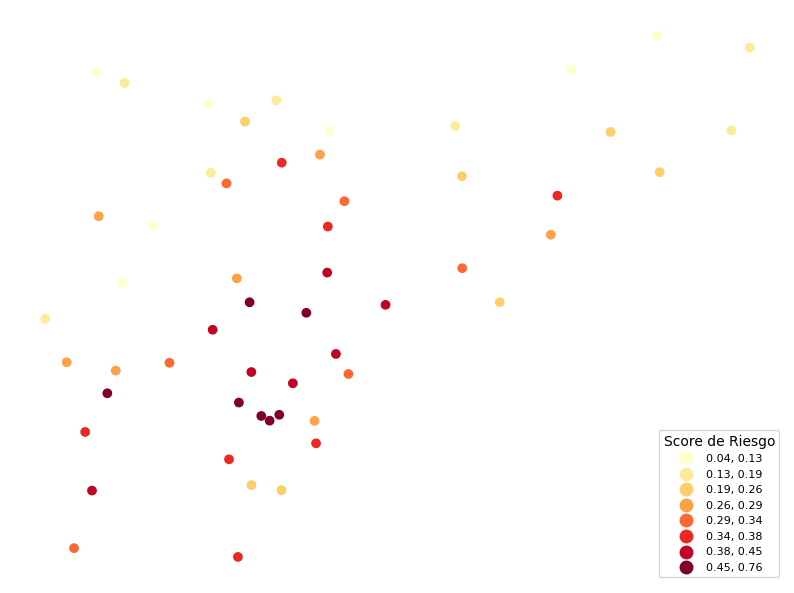

In [14]:
map=temp.plot(column='risk_score', 
         scheme='quantiles',
         k=8, cmap='YlOrRd',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Score de Riesgo'} 
)
map.set_axis_off()    

In [7]:
# Matriz de pesos por vecindad tipo torre
wr = weights.contiguity.Queen.from_dataframe(temp)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_17416\42047003.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wr = weights.contiguity.Queen.from_dataframe(temp)


In [8]:
print(wr.n)

55


In [9]:
wr.neighbors

{0: [26, 4, 28, 30],
 1: [25, 2, 19, 12],
 2: [1, 49, 19, 5, 37, 25],
 3: [49, 18, 5, 17],
 4: [0, 50, 30],
 5: [49, 2, 3, 37],
 6: [29, 7, 10, 11, 45, 46],
 7: [8, 29, 45, 6],
 8: [29, 20, 38, 7, 42, 45, 30],
 9: [46, 10, 22, 47],
 10: [29, 6, 22, 9, 11, 45, 46],
 11: [10, 6],
 12: [48, 1, 19, 51, 23, 15],
 13: [52, 44, 47],
 14: [16, 51, 35, 53, 15],
 15: [16, 51, 53, 12, 14],
 16: [53, 14, 15],
 17: [27, 18, 3, 54],
 18: [49, 17, 3, 37, 43, 27],
 19: [1, 2, 23, 39, 40, 25, 12],
 20: [21, 22, 8, 29, 30, 31],
 21: [32, 20, 22, 24, 29, 31],
 22: [20, 21, 24, 9, 10, 29],
 23: [48, 33, 34, 19, 36, 39, 12],
 24: [32, 33, 21, 22],
 25: [1, 2, 19, 37, 40],
 26: [0, 27, 28],
 27: [17, 18, 54, 26, 43, 28],
 28: [0, 39, 27, 26, 43, 30, 31],
 29: [6, 7, 8, 10, 20, 21, 22, 30],
 30: [0, 4, 38, 8, 50, 20, 28, 29, 31],
 31: [32, 20, 21, 39, 28, 30],
 32: [33, 21, 39, 24, 31],
 33: [32, 36, 23, 39, 24],
 34: [48, 35, 36, 23],
 35: [48, 34, 51, 14],
 36: [33, 34, 23],
 37: [49, 2, 18, 5, 40, 25, 43]

In [12]:
wr.islands

[]

In [10]:
print(wr.n**2)

print(wr.nonzero)


wr.pct_nonzero

3025
278


9.190082644628099

# Modelo XGBoost

In [104]:
# Carga de los datos 
df_train = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score_pointCoordinates.shp')
df_validation = gpd.read_file('../Input/ModelingDatasets/Validation/df_val_with_score_pointCoordinates.shp')
df_test = gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score_pointCoordinates.shp')

In [105]:
# Se hace una copia
train = df_train.copy()
val = df_validation.copy()
test = df_test.copy()
# Se extraen de manera individual las coordenadas
train['longitude'] = train.geometry.x
train['latitude'] = train.geometry.y
val['longitude'] = val.geometry.x
val['latitude'] = val.geometry.y
test['longitude'] = test.geometry.x
test['latitude'] = test.geometry.y

In [106]:
TARGET = 'risk_level'
# Se eliminan variables que a priori no se utilizaran
drop_cols = ['dispatch_d', 'crime_desc', 'geometry', 'risk_score']
X_train_model = train.drop(columns=drop_cols, errors='ignore')
X_valid_model = val.drop(columns=drop_cols, errors='ignore')
# X_test_model = test.drop(columns=drop_cols, errors='ignore')

y_train = train[TARGET]
y_valid = val[TARGET]
# y_test = test[TARGET]


In [107]:
# Se dividen las variables entre numericas o categoricas
num_features = [
    'dc_dist', 'hour', 'week_of_ye',
    'ZCTA', 'area_mile2', 'population', 'density_mi'
]

cat_features = [
    'psa', 'time_of_da',
    'day_of_wee', 'month', 'season',
    'crimeType', 'is_holiday'
]

# Asegurar que todas las columnas categóricas sean de tipo category
for col in cat_features:
    if col in X_train_model.columns:
        X_train_model[col] = X_train_model[col].astype(str)
        X_valid_model[col] = X_valid_model[col].astype(str)

In [108]:
X_train_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171737 entries, 0 to 171736
Data columns (total 17 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   dc_dist     171737 non-null  int64  
 1   psa         171737 non-null  object 
 2   hour        171737 non-null  int32  
 3   time_of_da  171737 non-null  object 
 4   day_of_wee  171737 non-null  object 
 5   week_of_ye  171737 non-null  int64  
 6   month       171737 non-null  object 
 7   season      171737 non-null  object 
 8   is_holiday  171737 non-null  object 
 9   crimeType   171737 non-null  object 
 10  ZCTA        171737 non-null  int64  
 11  area_mile2  171737 non-null  float64
 12  population  171737 non-null  int64  
 13  density_mi  171737 non-null  float64
 14  risk_level  171737 non-null  object 
 15  longitude   171737 non-null  float64
 16  latitude    171737 non-null  float64
dtypes: float64(4), int32(1), int64(4), object(8)
memory usage: 21.6+ MB


In [109]:
# Preprocesado de variables 
## Las numericas se estandarizan y las categorial se convierten en dummies
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ],
    remainder='drop'
)

# Transforma los datos primero
X_train_processed = preprocessor.fit_transform(X_train_model)
X_valid_processed = preprocessor.transform(X_valid_model)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Low=0, Moderate=1, High=2
y_valid_enc = le.transform(y_valid)

In [128]:
print(y_train)
print(y_train_enc)

0         Moderate
1         Moderate
2             High
3         Moderate
4         Moderate
            ...   
171732    Moderate
171733    Moderate
171734    Moderate
171735    Moderate
171736         Low
Name: risk_level, Length: 171737, dtype: object
[2 2 0 ... 2 2 1]


In [113]:
# ----------------------------
# Model
# ----------------------------
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    objective='multi:softprob',     # clasificación múltiple
    num_class=3,
    eval_metric='mlogloss'
)

In [ ]:
# Se ajustan los datos al modelo ya creado
xgb.fit(
    X_train_processed, 
    y_train_enc, 
    eval_set=[(X_valid_processed, y_valid_enc)], verbose=True
)

## Métricas para Regresión

In [ ]:
y_pred = np.clip(xgb.predict(X_valid_processed), 0.0, 1.0)

# Example evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("RMSE:", mean_squared_error(y_valid, y_pred, squared=False))
print("MAE:", mean_absolute_error(y_valid, y_pred))
print("R2:", r2_score(y_valid, y_pred))

RMSE: 0.20766635712143183
MAE: 0.1858715733956024
R2: -9.12918938967817


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


<Axes: >

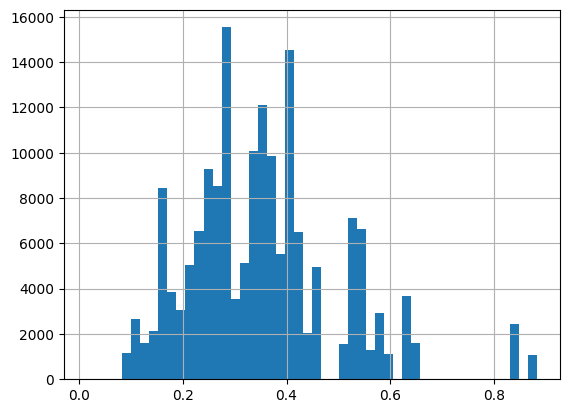

In [86]:
y_train.hist(bins=50)

## Métricas para Clasificación

In [123]:
y_pred = xgb.predict(X_valid_processed)
y_pred_labels = np.argmax(y_pred, axis=1)

In [124]:
y_pred = xgb.predict(X_valid_processed)
accuracy_score(y_valid_enc, y_pred_labels)

0.2158640226628895

In [125]:
cm = confusion_matrix(y_valid_enc, y_pred_labels)

In [126]:
cm

array([[  251,     0,     0],
       [ 3784,  6776, 20133],
       [ 2379,     0,   212]], dtype=int64)

In [127]:
print(classification_report(y_valid_enc, y_pred_labels))

              precision    recall  f1-score   support

           0       0.04      1.00      0.08       251
           1       1.00      0.22      0.36     30693
           2       0.01      0.08      0.02      2591

    accuracy                           0.22     33535
   macro avg       0.35      0.43      0.15     33535
weighted avg       0.92      0.22      0.33     33535

